# Term Deposit Prediction

Here we are given a dataset of a bank in Portugal. Our job here is to use the existing data to gather insights and build a ML model that will determine how likely a person will subscribe to a term deposit.This will help us assess the marketing campaign that will be most effective. We will also perform EDA to answer questions along the way. 

In [1]:
#loading the dataset

import pandas as pd

data=pd.read_excel('C:\\Users\\sujoydutta\\Desktop\\Data analysis\\Python\\Projects\\termdepositcampaign\\bank-full.xlsx')
data.head()

,age,job,marital,education,defaulter?,yearly_balance,housing_loan,personal_loan,contacted_via,day,month,duration_call_seconds,num_times_contacted,days_btw_contact,times_contact_before,pc_outcome,purchased?
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
#examining the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    45211 non-null  int64 
 1   job                    45211 non-null  object
 2   marital                45211 non-null  object
 3   education              45211 non-null  object
 4   defaulter?             45211 non-null  object
 5   yearly_balance         45211 non-null  int64 
 6   housing_loan           45211 non-null  object
 7   personal_loan          45211 non-null  object
 8   contacted_via          45211 non-null  object
 9   day                    45211 non-null  int64 
 10  month                  45211 non-null  object
 11  duration_call_seconds  45211 non-null  int64 
 12  num_times_contacted    45211 non-null  int64 
 13  days_btw_contact       45211 non-null  int64 
 14  times_contact_before   45211 non-null  int64 
 15  pc_outcome         

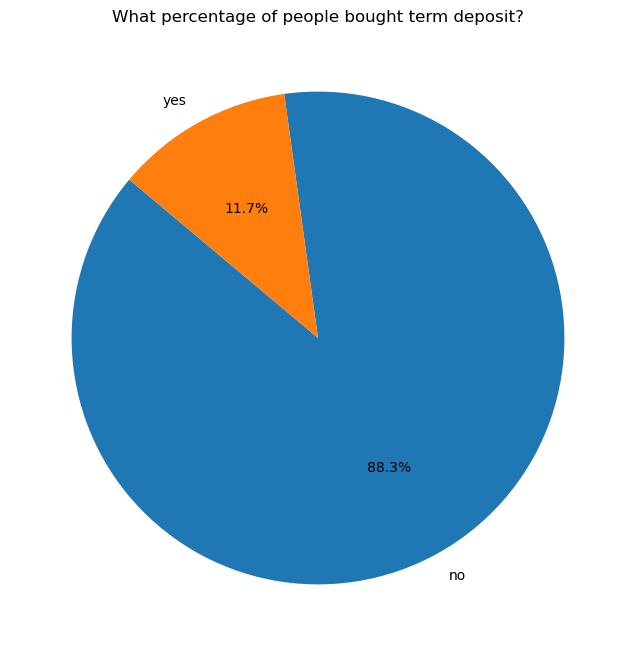

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pie chart to see the distribution of outcome
outcome_counts = data['purchased?'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('What percentage of people bought term deposit?')
plt.show()

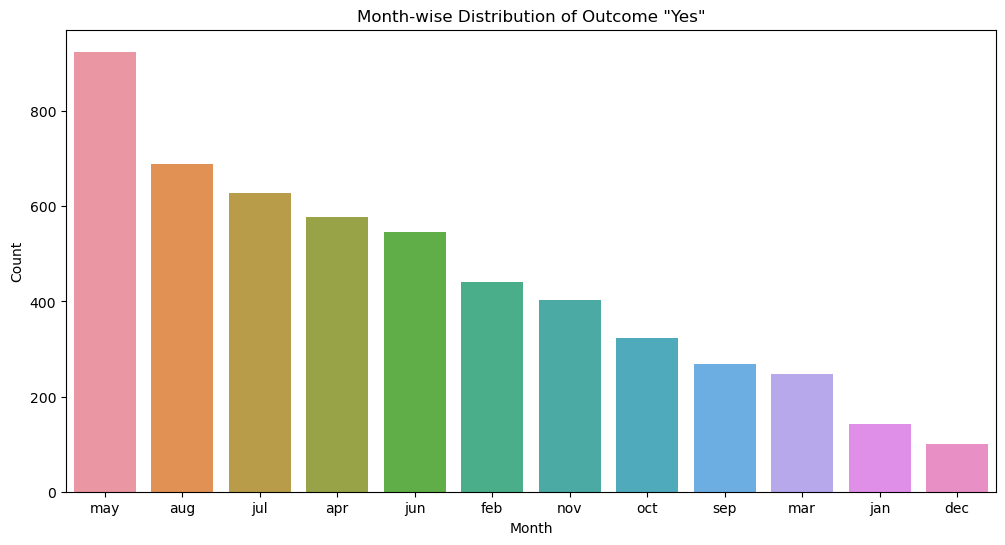

In [4]:
# Which month has highest conversion and which month has lowest conversion

df_yes = data[data['purchased?'] == 'yes']


plt.figure(figsize=(12, 6))
sns.countplot(data=df_yes, x='month', order=df_yes['month'].value_counts().index)
plt.title('Month-wise Distribution of Outcome "Yes"')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

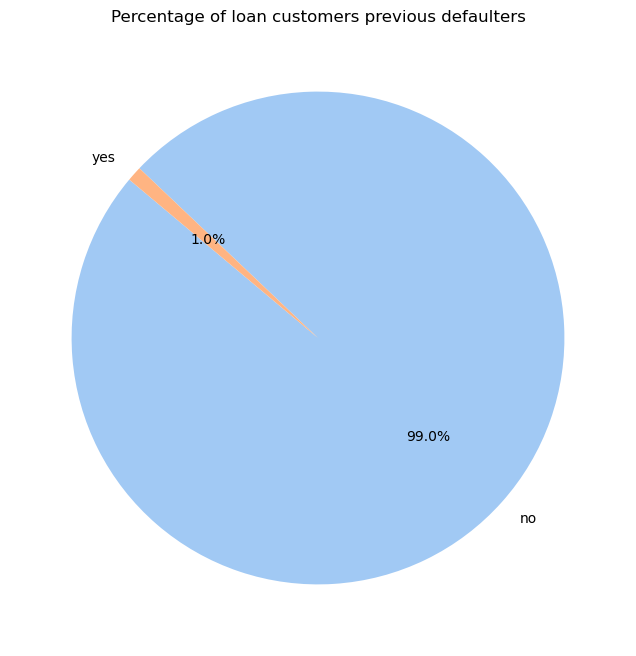

In [5]:
# what percentage of loan customers are previous defaulters?

df_yes = data[data['purchased?'] == 'yes']

default_counts = df_yes['defaulter?'].value_counts()


plt.figure(figsize=(8, 8))
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Percentage of loan customers previous defaulters')
plt.show()

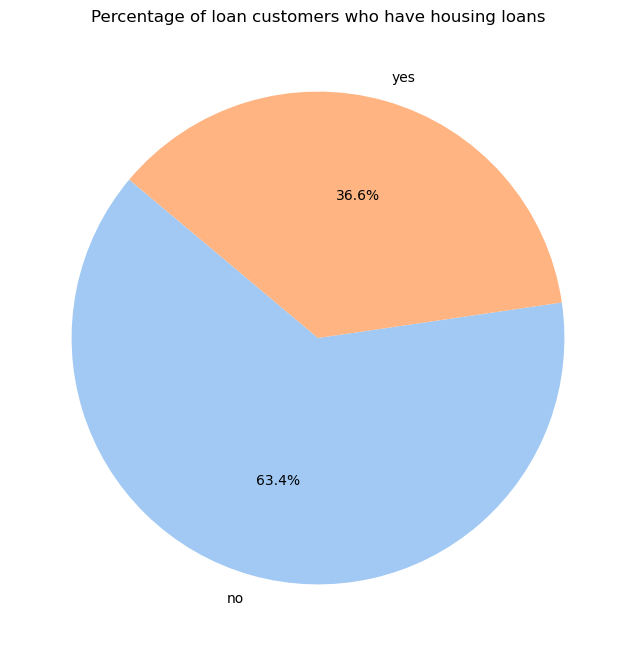

In [6]:
# what percentage of loan customers have Housing loans?

df_yes = data[data['purchased?'] == 'yes']

default_counts = df_yes['housing_loan'].value_counts()


plt.figure(figsize=(8, 8))
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Percentage of loan customers who have housing loans')
plt.show()

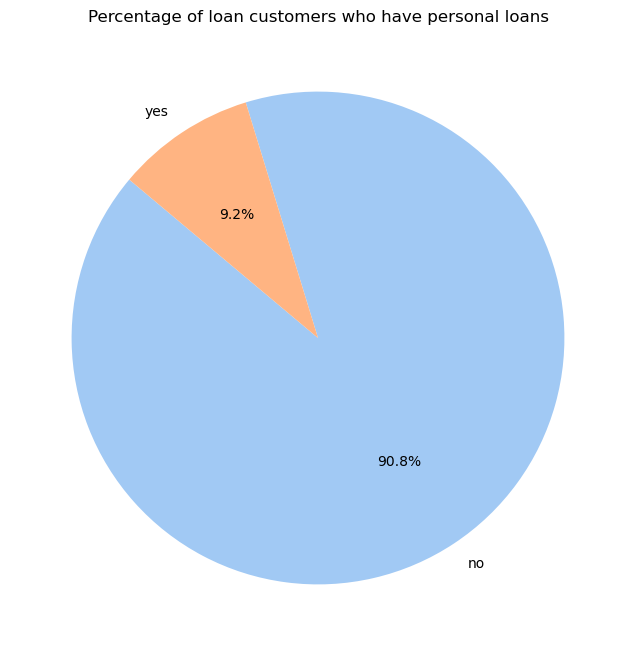

In [7]:
# what percentage of loan customers have personal loans?

df_yes = data[data['purchased?'] == 'yes']

default_counts = df_yes['personal_loan'].value_counts()


plt.figure(figsize=(8, 8))
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Percentage of loan customers who have personal loans')
plt.show()

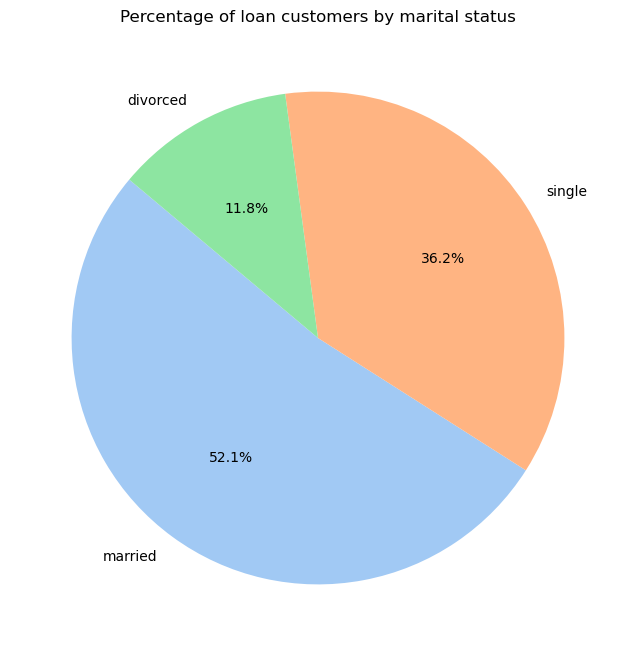

In [8]:
# Share of each marital status that purchased the term deposit

df_yes = data[data['purchased?'] == 'yes']

default_counts = df_yes['marital'].value_counts()


plt.figure(figsize=(8, 8))
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Percentage of loan customers by marital status')
plt.show()

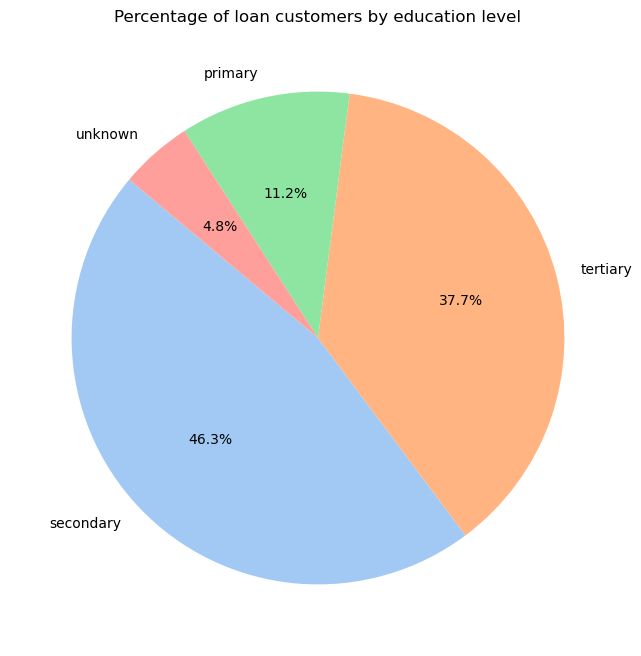

In [9]:
# Share of each education level that purchased the term deposit

df_yes = data[data['purchased?'] == 'yes']

default_counts = df_yes['education'].value_counts()


plt.figure(figsize=(8, 8))
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Percentage of loan customers by education level')
plt.show()

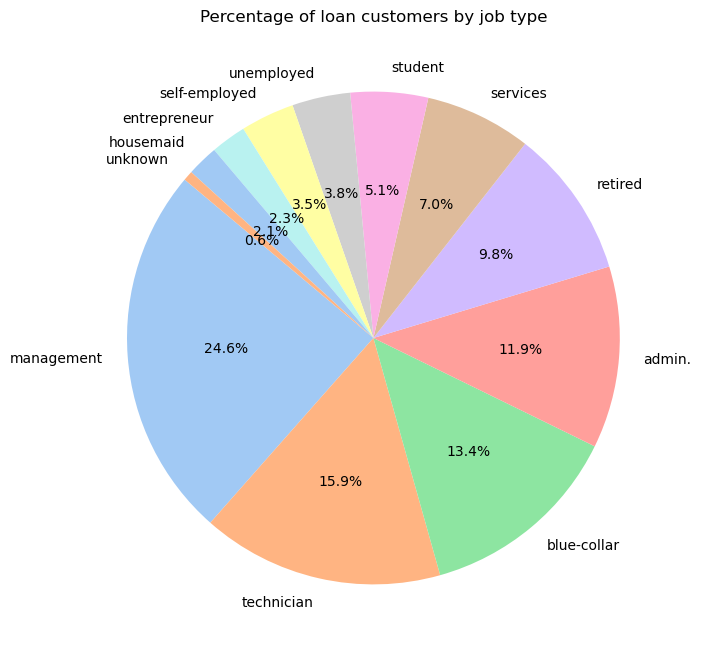

In [10]:
# Share of each profession type that purchased the term deposit

df_yes = data[data['purchased?'] == 'yes']

default_counts = df_yes['job'].value_counts()


plt.figure(figsize=(8, 8))
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Percentage of loan customers by job type')
plt.show()

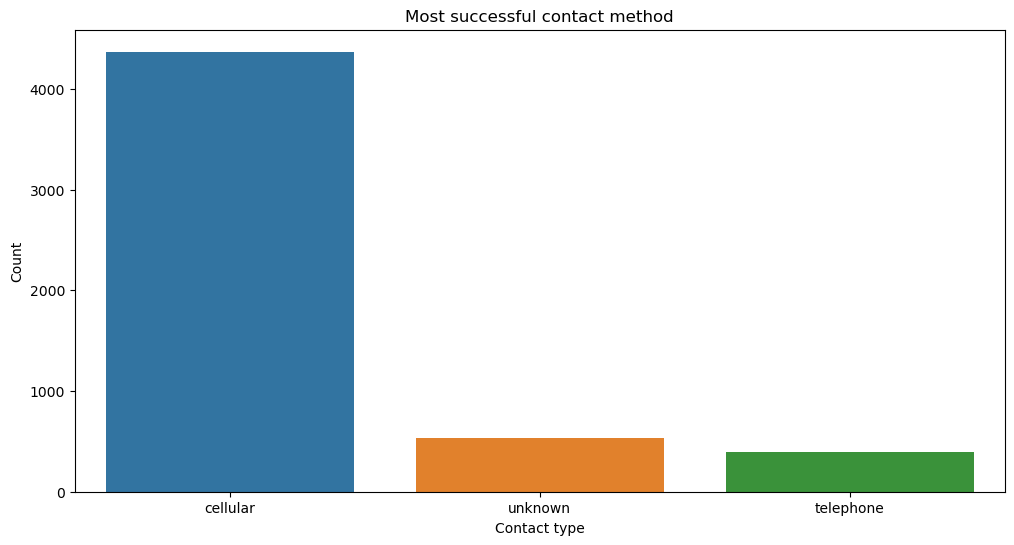

In [11]:
# Which medium of communication has highest conversion and which one has lowest conversion

df_yes = data[data['purchased?'] == 'yes']


plt.figure(figsize=(12, 6))
sns.countplot(data=df_yes, x='contacted_via', order=df_yes['contacted_via'].value_counts().index)
plt.title('Most successful contact method')
plt.xlabel('Contact type')
plt.ylabel('Count')
plt.show()

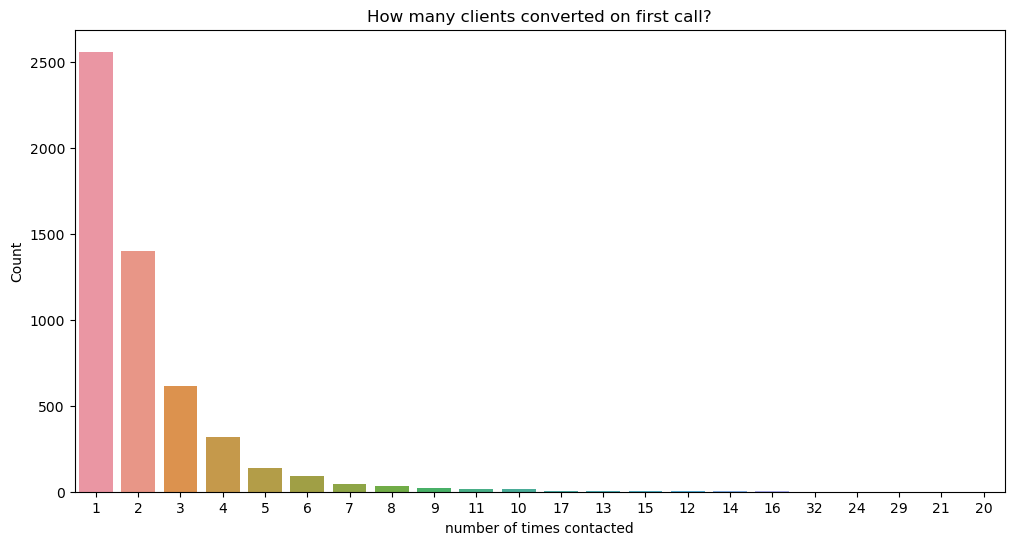

In [12]:
# How many clients converted on the first call?

df_yes = data[data['purchased?'] == 'yes']


plt.figure(figsize=(12, 6))
sns.countplot(data=df_yes, x='num_times_contacted', order=df_yes['num_times_contacted'].value_counts().index)
plt.title('How many clients converted on first call?')
plt.xlabel('number of times contacted')
plt.ylabel('Count')
plt.show()

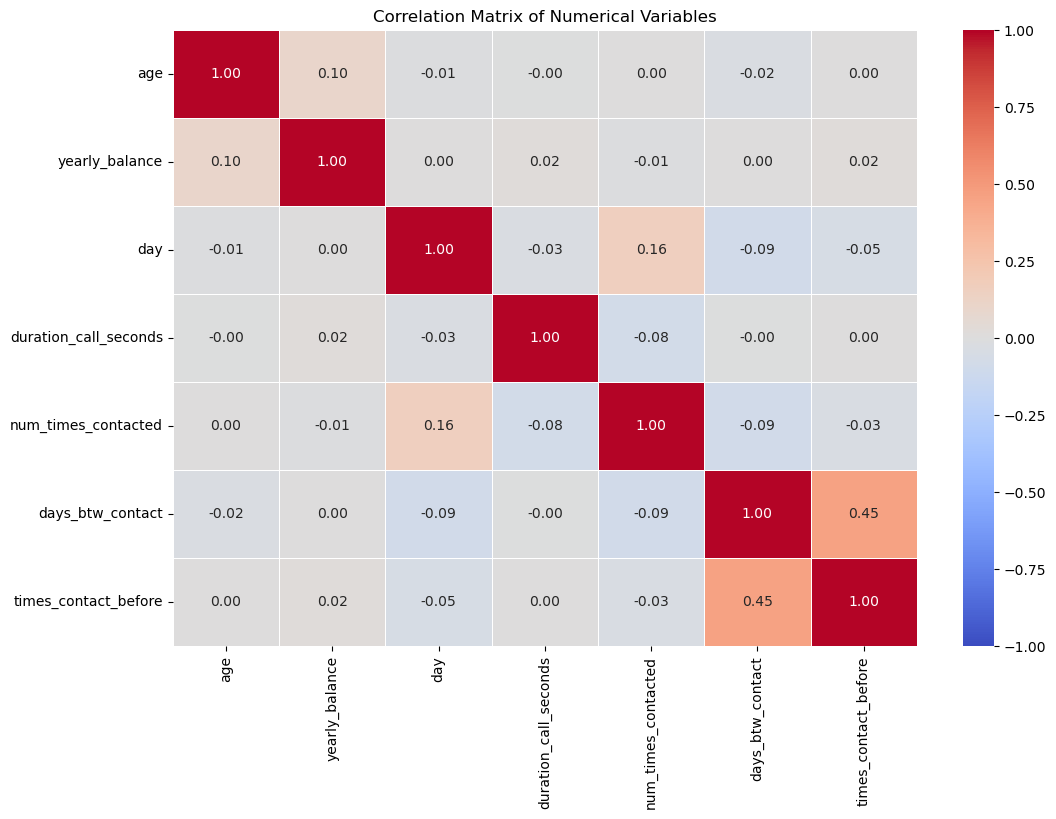

In [13]:
# Seeing the correlation among numerical variables
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns
numerical_data = data[numerical_columns]


corr_matrix = numerical_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

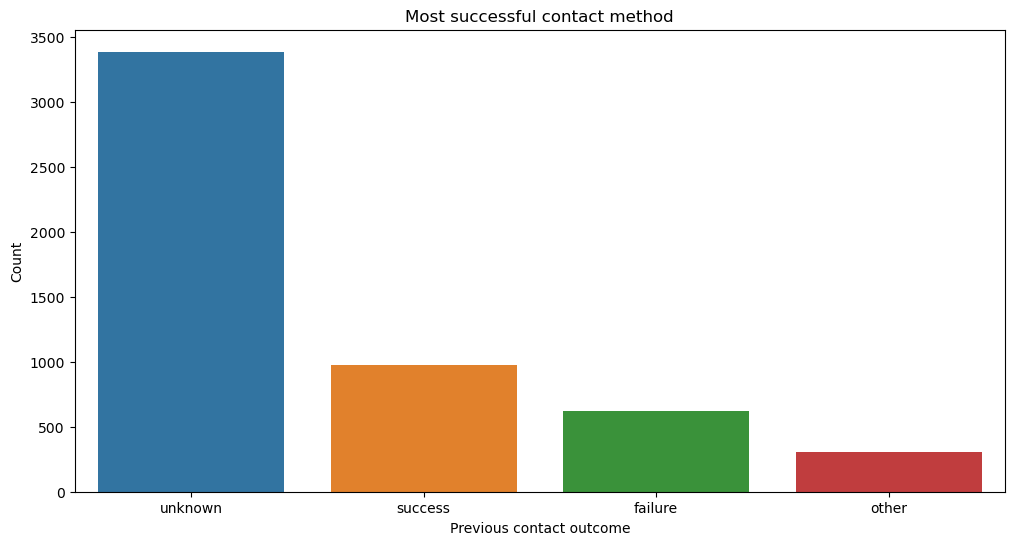

In [14]:
# What should be the outcome of previous contact to get a term deposit conversion>

df_yes = data[data['purchased?'] == 'yes']


plt.figure(figsize=(12, 6))
sns.countplot(data=df_yes, x='pc_outcome', order=df_yes['pc_outcome'].value_counts().index)
plt.title('Most successful contact method')
plt.xlabel('Previous contact outcome')
plt.ylabel('Count')
plt.show()

C:\Users\sujoydutta\AppData\Local\Temp\ipykernel_12728\1407996061.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data['age'], shade=True, color='skyblue')


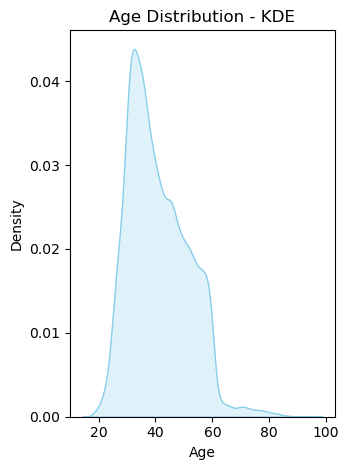

In [15]:
# Viewing age distribution of the campaign target
plt.subplot(1, 2, 2)
sns.kdeplot(data['age'], shade=True, color='skyblue')
plt.title('Age Distribution - KDE')
plt.xlabel('Age')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

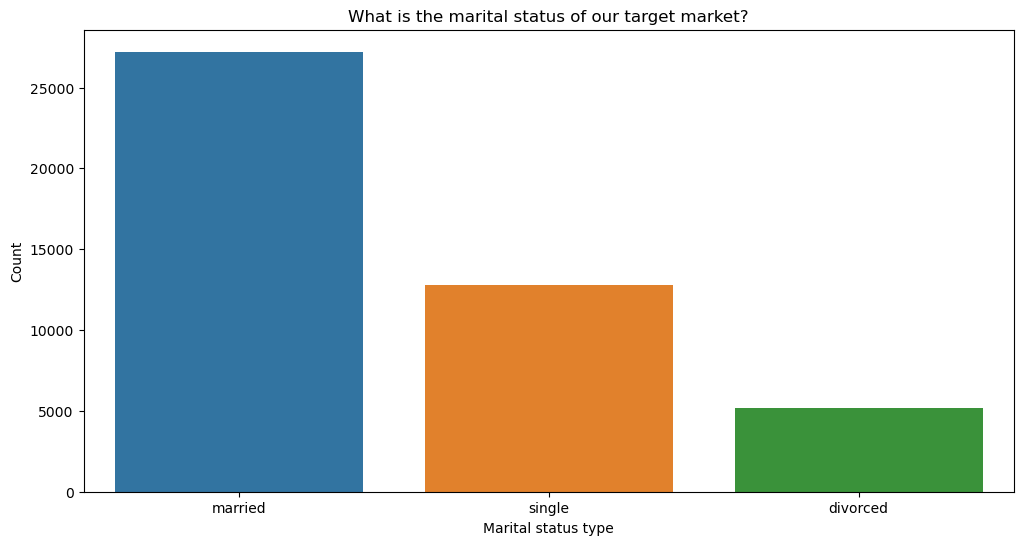

In [16]:
# Marital status distribution of the target group



plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='marital', order=data['marital'].value_counts().index)
plt.title('What is the marital status of our target market?')
plt.xlabel('Marital status type')
plt.ylabel('Count')
plt.show()

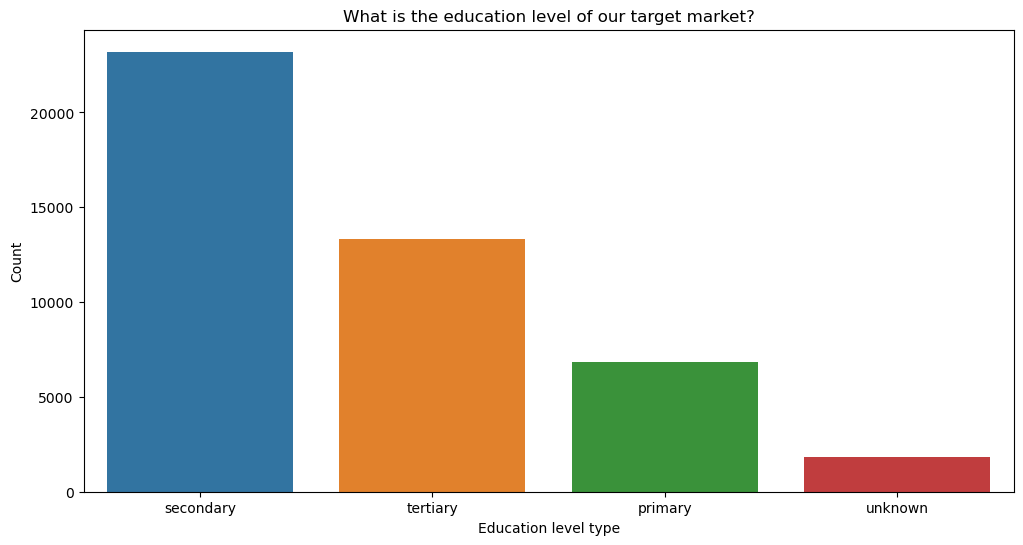

In [17]:
# level of education distribution of the target group



plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='education', order=data['education'].value_counts().index)
plt.title('What is the education level of our target market?')
plt.xlabel('Education level type')
plt.ylabel('Count')
plt.show()

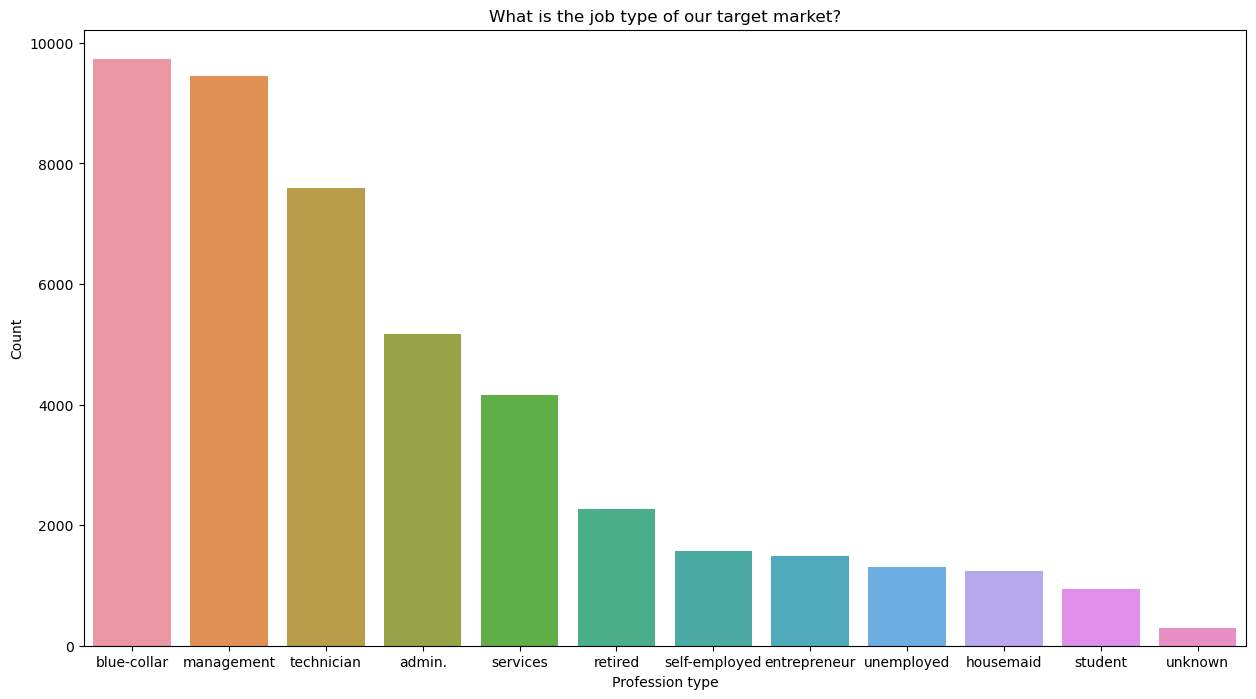

In [18]:
# Type of profession the target group engages in



plt.figure(figsize=(15, 8))
sns.countplot(data=data, x='job', order=data['job'].value_counts().index)
plt.title('What is the job type of our target market?')
plt.xlabel('Profession type')
plt.ylabel('Count')
plt.show()

In [19]:
# Filtering the dataset based on the outcome
purchased = data[data['purchased?'] == 'yes']
not_purchased = data[data['purchased?'] == 'no']


In [20]:
import numpy as np
from scipy import stats

# Function to perform z-test
def z_test(group1, group2, variable):
    mean1 = group1[variable].mean()
    mean2 = group2[variable].mean()
    std1 = group1[variable].std()
    std2 = group2[variable].std()
    n1 = len(group1[variable])
    n2 = len(group2[variable])
    
    z = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
    p = 2 * (1 - stats.norm.cdf(abs(z))) 
    return z, p

In [21]:
# Performing z-test for each variable
variables = ['num_times_contacted', 'days_btw_contact','yearly_balance','duration_call_seconds','times_contact_before','age']


results = {}
for var in variables:
    z, p = z_test(purchased, not_purchased, var)
    results[var] = {'z-score': z, 'p-value': p}


results_df = pd.DataFrame(results).T
print(results_df)

                         z-score   p-value
num_times_contacted   -22.800741  0.000000
days_btw_contact       18.943484  0.000000
yearly_balance          9.933545  0.000000
duration_call_seconds  57.514127  0.000000
times_contact_before   18.117970  0.000000
age                     4.318318  0.000016


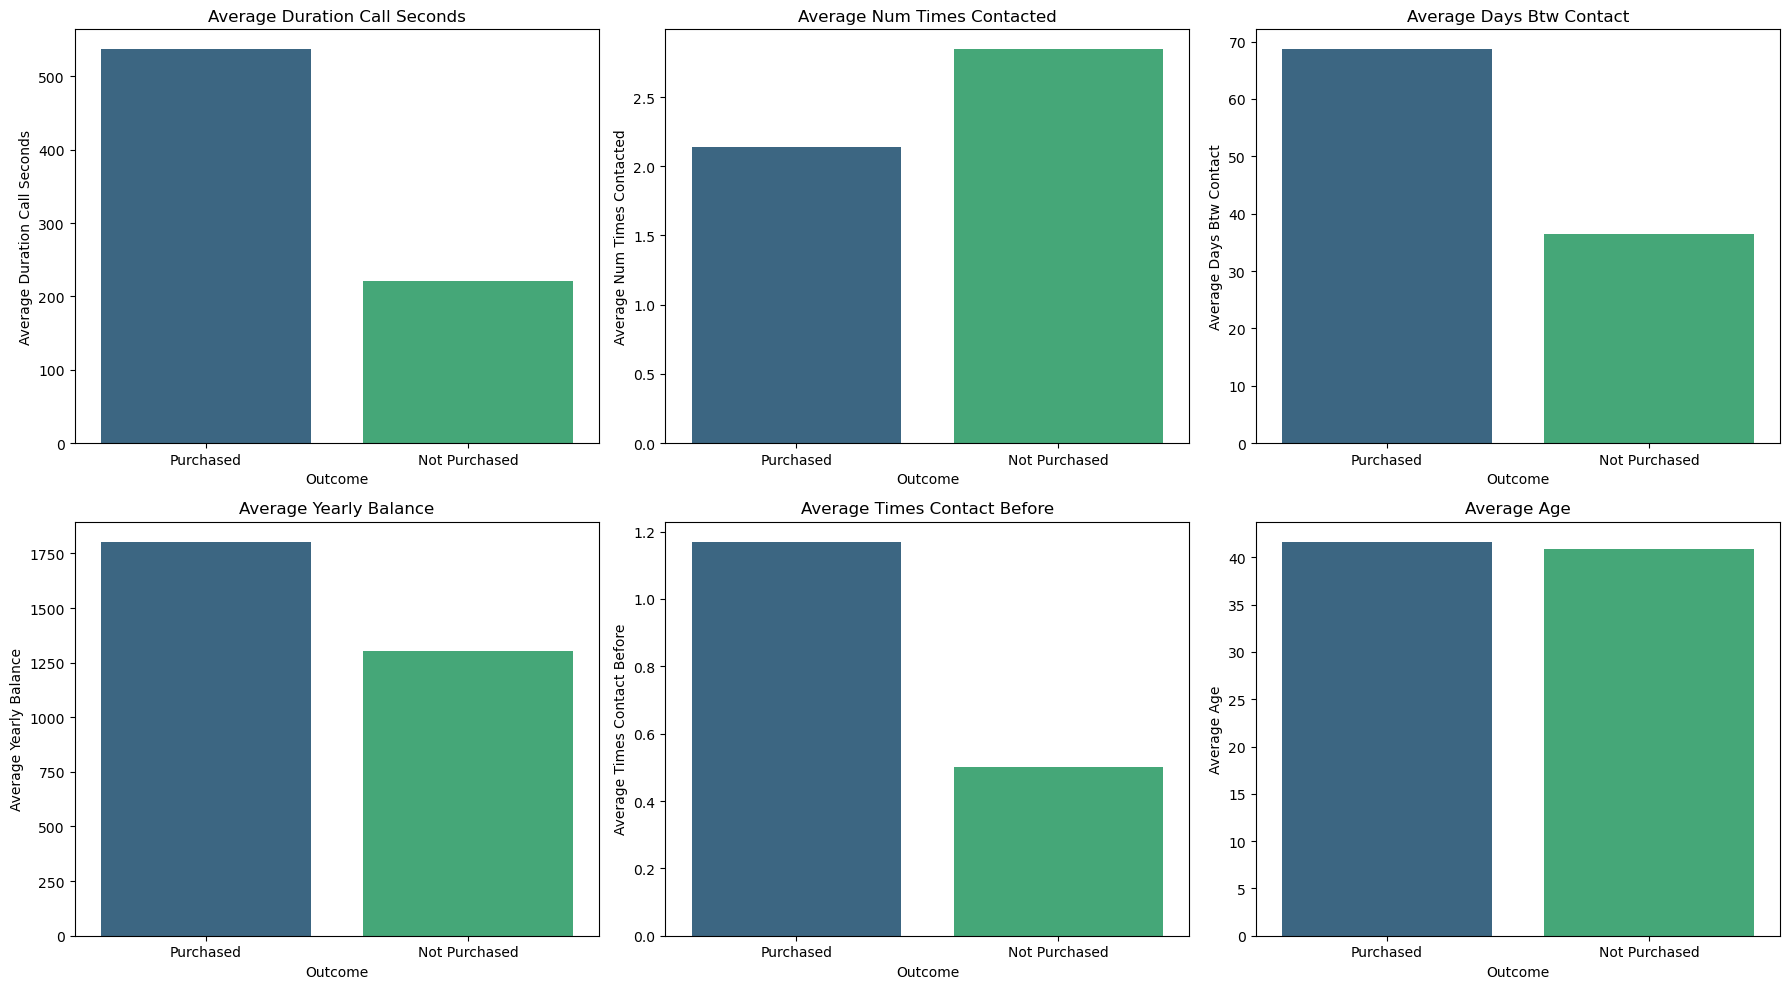

In [22]:
#visualizing the difference
variables = ['duration_call_seconds', 'num_times_contacted', 'days_btw_contact','yearly_balance','times_contact_before','age']
means_purchased = purchased[variables].mean()
means_not_purchased = not_purchased[variables].mean()


means_df = pd.DataFrame({
    'Purchased': means_purchased,
    'Not Purchased': means_not_purchased
}).T



plt.figure(figsize=(18, 10))

for i, var in enumerate(variables):
    plt.subplot(2, 3, i + 1)
    sns.barplot(data=means_df[[var]].reset_index(), x='index', y=var, palette='viridis')
    plt.title(f'Average {var.replace("_", " ").title()}')
    plt.xlabel('Outcome')
    plt.ylabel(f'Average {var.replace("_", " ").title()}')


if len(variables) < 6:
    plt.subplot(2, 3, 6).axis('off')

plt.tight_layout()
plt.show()

In [23]:


# Function to identify outliers using Z-score
def identify_outliers_zscore(df, threshold=3):
    outliers = (np.abs(stats.zscore(df)) > threshold).any(axis=1)
    return outliers

In [24]:
# Identifying outliers in the numerical columns
numerical_columns = ['age','yearly_balance','duration_call_seconds', 'num_times_contacted', 'days_btw_contact', 'times_contact_before']

outliers = identify_outliers_zscore(data[numerical_columns])
outliers

0        False
1        False
2        False
3        False
4        False
         ...  
45206    False
45207    False
45208     True
45209    False
45210     True
Length: 45211, dtype: bool

In [25]:
# Analyzing the effect of outliers
data_no_outliers = data[~outliers]
data_with_outliers = data[outliers]

In [26]:
# Comparing the datasets
print(f'Original dataset size: {data.shape[0]}')
print(f'Dataset size without outliers: {data_no_outliers.shape[0]}')
print(f'Dataset size with outliers: {data_with_outliers.shape[0]}')

Original dataset size: 45211
Dataset size without outliers: 40209
Dataset size with outliers: 5002


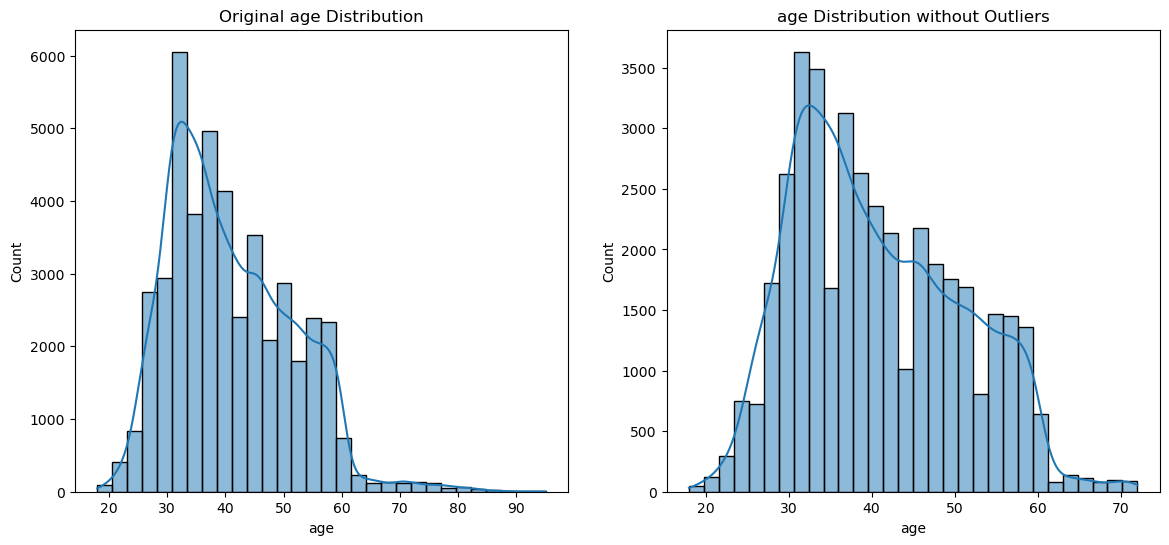

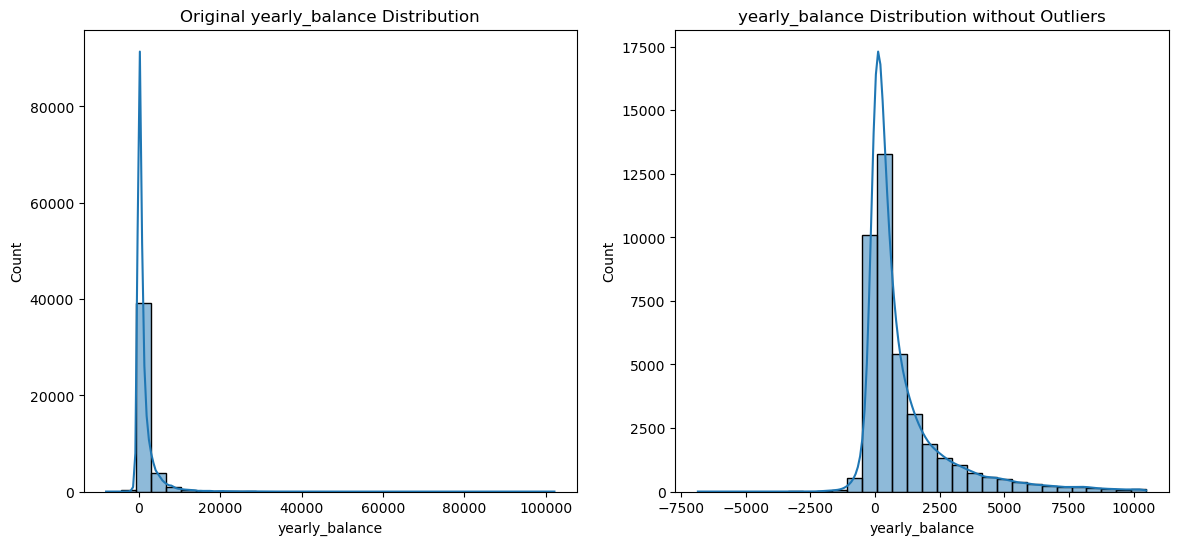

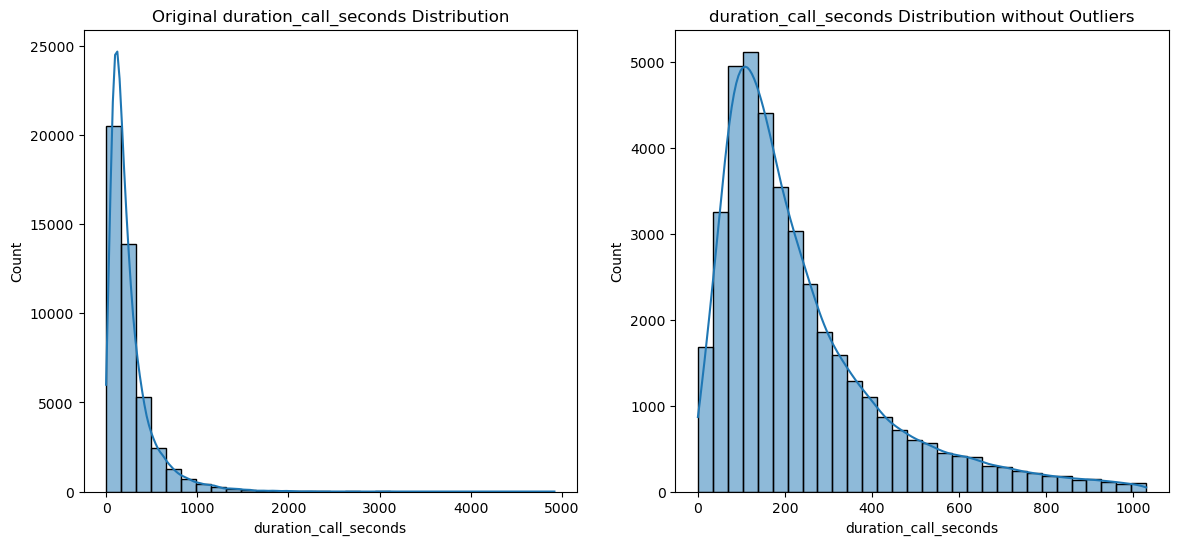

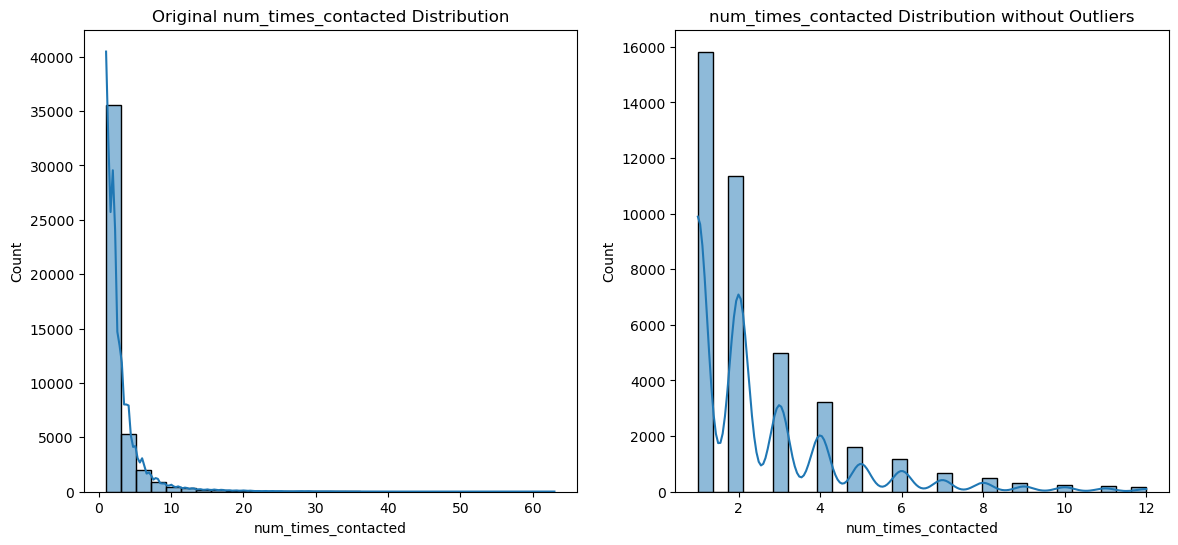

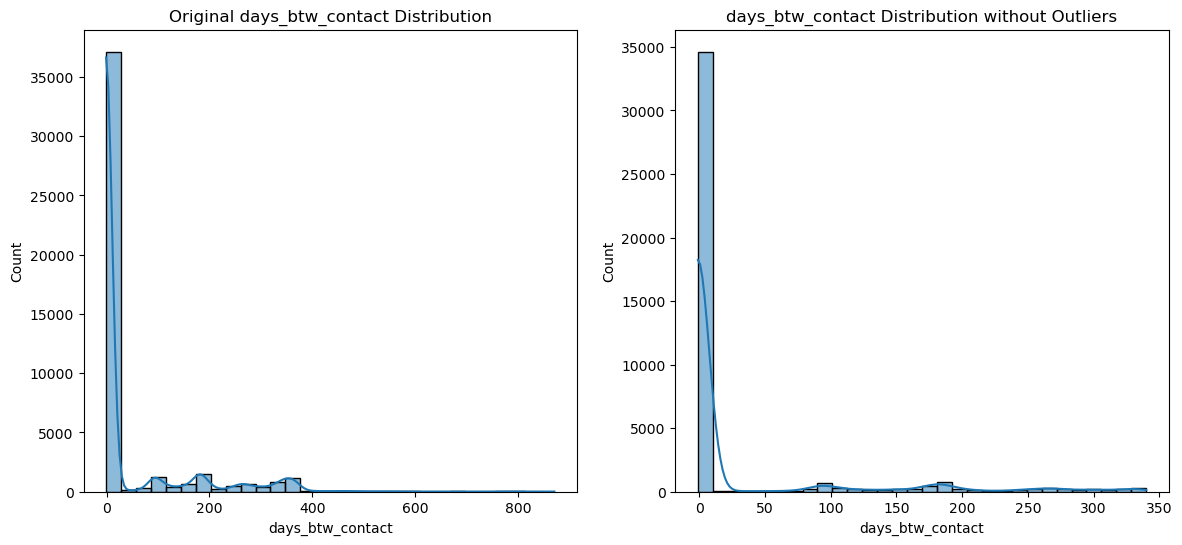

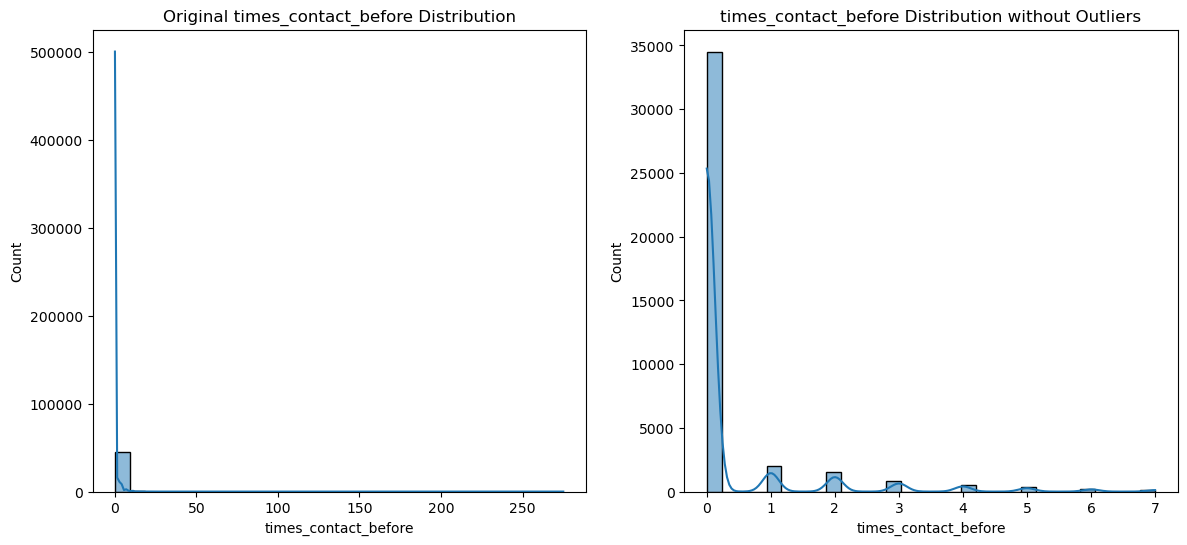

In [27]:
# Visualizing the distributions before and after outlier removal
for col in numerical_columns:
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Original {col} Distribution')

    plt.subplot(1, 2, 2)
    sns.histplot(data_no_outliers[col], bins=30, kde=True)
    plt.title(f'{col} Distribution without Outliers')

    plt.show()

In [28]:
# Replacing outliers with median values
for col in numerical_columns:
    median = data[col].median()
    data.loc[outliers, col] = median

In [29]:
# Checking if outliers are replaced
print(data.describe())


                age  yearly_balance           day  duration_call_seconds  \
count  45211.000000    45211.000000  45211.000000           45211.000000   
mean      40.476101     1013.160249     15.806419             229.621773   
std        9.526543     1636.907495      8.322476             180.417341   
min       18.000000    -6847.000000      1.000000               0.000000   
25%       33.000000       99.000000      8.000000             112.000000   
50%       39.000000      448.000000     16.000000             180.000000   
75%       47.000000     1161.000000     21.000000             283.000000   
max       72.000000    10483.000000     31.000000            1030.000000   

       num_times_contacted  days_btw_contact  times_contact_before  
count         45211.000000      45211.000000          45211.000000  
mean              2.412953         22.287364              0.313618  
std               1.846032         68.173144              1.002829  
min               1.000000         -1.0

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Calculating VIF for each feature
X = data[numerical_columns]
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                 Feature       VIF
0                    age  4.309325
1         yearly_balance  1.405196
2  duration_call_seconds  2.403441
3    num_times_contacted  2.549530
4       days_btw_contact  2.322813
5   times_contact_before  2.309668


In [31]:
# Define categorical and numerical columns
categories = ['job', 'marital', 'education','day', 'defaulter?', 'housing_loan', 'personal_loan', 'contacted_via', 'month', 'pc_outcome']
numerical_columns = ['duration_call_seconds', 'num_times_contacted', 'days_btw_contact', 'yearly_balance', 'times_contact_before']

In [32]:
# Define target column
target = 'purchased?'

# Preparing feature matrix and target vector
X = data[categories + numerical_columns]
y = data[target].map({'yes': 1, 'no': 0})


In [35]:
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
# Defining preprocessing steps
numeric_transformer = StandardScaler()  
categorical_transformer = ce.BinaryEncoder(cols=categories)

In [36]:
from sklearn.compose import ColumnTransformer

# Combining preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_columns),
        ('cat', categorical_transformer, categories)
    ])

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# Defining the model pipeline
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression())])


In [38]:
from sklearn.model_selection import train_test_split

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [39]:
# Fitting the model
model.fit(X_train, y_train)


C:\Users\sujoydutta\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration_call_seconds',
                                                   'num_times_contacted',
                                                   'days_btw_contact',
                                                   'yearly_balance',
                                                   'times_contact_before']),
                                                 ('cat',
                                                  BinaryEncoder(cols=['job',
                                                                      'marital',
                                                                      'education',
                                                                      'day',
                                                                      'defaulter?',
                                                                      'housing_loan',
                                                                      'personal_loan',
                                                                      'contacted_via',
                                                                      'month',
                                                                      'pc_outcome']),
                                                  ['job', 'marital',
                                                   'education', 'day',
                                                   'defaulter?', 'housing_loan',
                                                   'personal_loan',
                                                   'contacted_via', 'month',
                                                   'pc_outcome'])])),
                ('classifier', LogisticRegression())])

In [40]:
# Predicting on the test set
y_pred = model.predict(X_test)

In [41]:
# Evaluating the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8948066884897815
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      9950
           1       0.64      0.28      0.39      1353

    accuracy                           0.89     11303
   macro avg       0.77      0.63      0.67     11303
weighted avg       0.88      0.89      0.88     11303

Confusion Matrix:
[[9736  214]
 [ 975  378]]


In [42]:
# Example with Logistic Regression
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression(class_weight='balanced'))])


In [43]:
# Fitting the model
model.fit(X_train, y_train)


C:\Users\sujoydutta\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration_call_seconds',
                                                   'num_times_contacted',
                                                   'days_btw_contact',
                                                   'yearly_balance',
                                                   'times_contact_before']),
                                                 ('cat',
                                                  BinaryEncoder(cols=['job',
                                                                      'marital',
                                                                      'education',
                                                                      'day',
                                                                      'defaulter?',
                                                                      'housing_loan',
                                                                      'personal_loan',
                                                                      'contacted_via',
                                                                      'month',
                                                                      'pc_outcome']),
                                                  ['job', 'marital',
                                                   'education', 'day',
                                                   'defaulter?', 'housing_loan',
                                                   'personal_loan',
                                                   'contacted_via', 'month',
                                                   'pc_outcome'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [44]:
# Predicting on the test set
y_pred = model.predict(X_test)

In [45]:
# Evaluating the model

print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7860744934973016
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      9950
           1       0.33      0.75      0.46      1353

    accuracy                           0.79     11303
   macro avg       0.64      0.77      0.66     11303
weighted avg       0.88      0.79      0.82     11303

Confusion Matrix:
[[7868 2082]
 [ 336 1017]]


In [46]:
from sklearn.ensemble import RandomForestClassifier
# Example with Random Forest Classifier
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))])


In [47]:
# Fitting the model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration_call_seconds',
                                                   'num_times_contacted',
                                                   'days_btw_contact',
                                                   'yearly_balance',
                                                   'times_contact_before']),
                                                 ('cat',
                                                  BinaryEncoder(cols=['job',
                                                                      'marital',
                                                                      'education',
                                                                      'day',
                                                                      'defaulter?',
                                                                      'housing_loan',
                                                                      'personal_loan',
                                                                      'contacted_via',
                                                                      'month',
                                                                      'pc_outcome']),
                                                  ['job', 'marital',
                                                   'education', 'day',
                                                   'defaulter?', 'housing_loan',
                                                   'personal_loan',
                                                   'contacted_via', 'month',
                                                   'pc_outcome'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [48]:
# Evaluating the model

print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7860744934973016
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      9950
           1       0.33      0.75      0.46      1353

    accuracy                           0.79     11303
   macro avg       0.64      0.77      0.66     11303
weighted avg       0.88      0.79      0.82     11303

Confusion Matrix:
[[7868 2082]
 [ 336 1017]]


In [49]:
from sklearn.ensemble import GradientBoostingClassifier
# Example with Gradient Boosting Classifier
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', GradientBoostingClassifier(random_state=42))])


In [50]:
# Fitting the model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration_call_seconds',
                                                   'num_times_contacted',
                                                   'days_btw_contact',
                                                   'yearly_balance',
                                                   'times_contact_before']),
                                                 ('cat',
                                                  BinaryEncoder(cols=['job',
                                                                      'marital',
                                                                      'education',
                                                                      'day',
                                                                      'defaulter?',
                                                                      'housing_loan',
                                                                      'personal_loan',
                                                                      'contacted_via',
                                                                      'month',
                                                                      'pc_outcome']),
                                                  ['job', 'marital',
                                                   'education', 'day',
                                                   'defaulter?', 'housing_loan',
                                                   'personal_loan',
                                                   'contacted_via', 'month',
                                                   'pc_outcome'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [51]:
# Predicting on the test set
y_pred = model.predict(X_test)

In [52]:
# Evaluating the model

print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8956029372732903
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      9950
           1       0.65      0.27      0.38      1353

    accuracy                           0.90     11303
   macro avg       0.78      0.63      0.66     11303
weighted avg       0.88      0.90      0.88     11303

Confusion Matrix:
[[9757  193]
 [ 987  366]]


In [86]:
# Defining the parameter grid for GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.1, 0.05, 0.01],
    'classifier__max_depth': [3, 4, 5],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__subsample': [0.6, 0.7, 0.8],
    'classifier__max_features': [None, 'sqrt', 'log2']
}


In [87]:
#building the pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', GradientBoostingClassifier(random_state=42))])


In [88]:
from sklearn.experimental import enable_halving_search_cv  
from sklearn.model_selection import HalvingGridSearchCV

# Performing GridSearchCV to find the best parameters
grid_search = HalvingGridSearchCV(pipeline, param_grid, cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X, y)


n_iterations: 8
n_required_iterations: 8
n_possible_iterations: 8
min_resources_: 20
max_resources_: 45211
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 2187
n_resources: 20
Fitting 5 folds for each of 2187 candidates, totalling 10935 fits
----------
iter: 1
n_candidates: 729
n_resources: 60
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
----------
iter: 2
n_candidates: 243
n_resources: 180
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
----------
iter: 3
n_candidates: 81
n_resources: 540
Fitting 5 folds for each of 81 candidates, totalling 405 fits
----------
iter: 4
n_candidates: 27
n_resources: 1620
Fitting 5 folds for each of 27 candidates, totalling 135 fits
----------
iter: 5
n_candidates: 9
n_resources: 4860
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 6
n_candidates: 3
n_resources: 14580
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 7
n_candidates: 1
n_res

HalvingGridSearchCV(estimator=Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['duration_call_seconds',
                                                                                 'num_times_contacted',
                                                                                 'days_btw_contact',
                                                                                 'yearly_balance',
                                                                                 'times_contact_before']),
                                                                               ('cat',
                                                                                BinaryEncoder(cols=['job',
                                                                                                    'marital',
                                                                                                    'education',
                                                                                                    'day',
                                                                                                    'defaulter?',
                                                                                                    'housing_loan',
                                                                                                    'personal_loan',
                                                                                                    'contacted_via',
                                                                                                    'mo...
                                               GradientBoostingClassifier(random_state=42))]),
                    n_jobs=-1,
                    param_grid={'classifier__learning_rate': [0.1, 0.05, 0.01],
                                'classifier__max_depth': [3, 4, 5],
                                'classifier__max_features': [None, 'sqrt',
                                                             'log2'],
                                'classifier__min_samples_leaf': [1, 2, 4],
                                'classifier__min_samples_split': [2, 5, 10],
                                'classifier__n_estimators': [50, 100, 200],
                                'classifier__subsample': [0.6, 0.7, 0.8]},
                    verbose=1)

In [89]:
# Printing the best parameters 
print("Best parameters found:")
print(grid_search.best_params_)


Best parameters found:
{'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50, 'classifier__subsample': 0.6}


In [90]:
# Printing the best score
print("Best CV score:")
print(grid_search.best_score_)

Best CV score:
0.883254061265711


In [92]:
# Best parameters from GridSearchCV
best_params = {
    'learning_rate': 0.01,
    'max_depth': 5,
    'max_features': 'log2',
    'min_samples_leaf': 2,
    'min_samples_split': 5,
    'n_estimators': 50,
    'subsample': 0.6
}


In [93]:
# Created the final model with the best parameters
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(**best_params, random_state=42))
])


In [94]:
# Fitting the model
final_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration_call_seconds',
                                                   'num_times_contacted',
                                                   'days_btw_contact',
                                                   'yearly_balance',
                                                   'times_contact_before']),
                                                 ('cat',
                                                  BinaryEncoder(cols=['job',
                                                                      'marital',
                                                                      'education',
                                                                      'day',
                                                                      'defaulter?',
                                                                      'housing_loan',
                                                                      'personal_loan',
                                                                      'contacted_via',
                                                                      'month',
                                                                      'pc_outcome']),
                                                  ['job', 'marital',
                                                   'education', 'day',
                                                   'defaulter?', 'housing_loan',
                                                   'personal_loan',
                                                   'contacted_via', 'month',
                                                   'pc_outcome'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.01, max_depth=5,
                                            max_features='log2',
                                            min_samples_leaf=2,
                                            min_samples_split=5,
                                            n_estimators=50, random_state=42,
                                            subsample=0.6))])

In [95]:
# Printing the training accuracy
train_score = final_model.score(X_train, y_train)
print("Training Accuracy: ", train_score)

Training Accuracy:  0.8839211985372184


In [96]:
# Printing the test accuracy
test_score = final_model.score(X_test, y_test)
print("Test Accuracy: ", test_score)

Test Accuracy:  0.8802972662125099


In [97]:
# Evaluating the model

print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8956029372732903
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      9950
           1       0.65      0.27      0.38      1353

    accuracy                           0.90     11303
   macro avg       0.78      0.63      0.66     11303
weighted avg       0.88      0.90      0.88     11303

Confusion Matrix:
[[9757  193]
 [ 987  366]]


In [98]:
#getting the importance of variables
feature_importances = final_model.named_steps['classifier'].feature_importances_


In [99]:
# Lets combine the names of numerical and categorical features
feature_names = (
    final_model.named_steps['preprocessor']
    .transformers_[0][2] +  # Numerical features
    final_model.named_steps['preprocessor']
    .transformers_[1][1]  # OneHotEncoder feature names
    .get_feature_names_out(final_model.named_steps['preprocessor']
    .transformers_[1][2]).tolist()
)

In [100]:
# Creating a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)


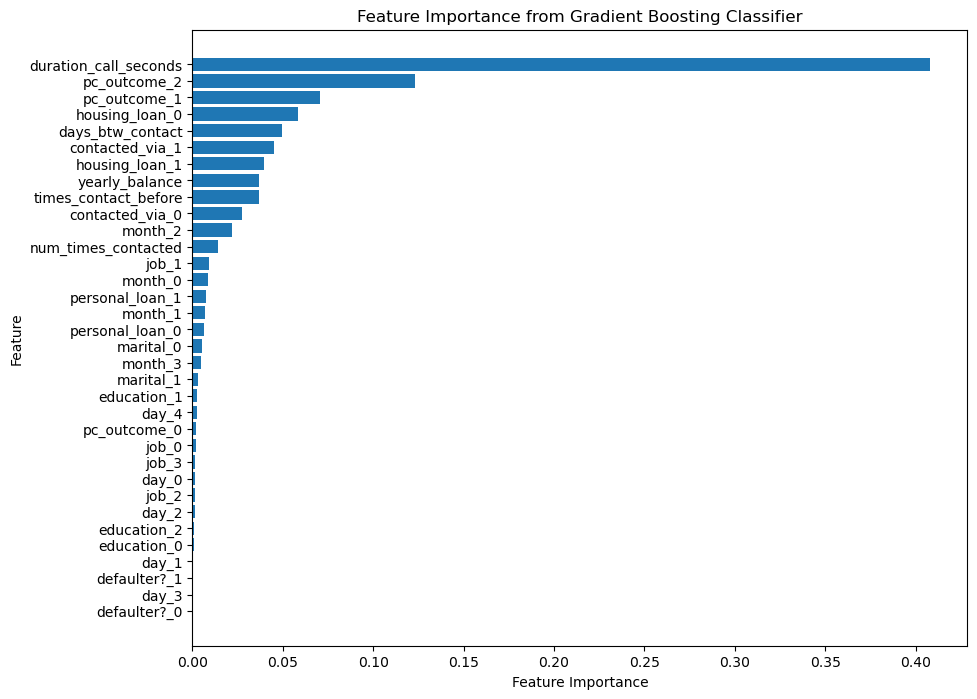

In [101]:
# Plotting the feature importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Gradient Boosting Classifier')
plt.gca().invert_yaxis()
plt.show()